In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("Dataset.csv")  # File name exact

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df = df.drop(["id", "Unnamed: 32"], axis=1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]  # first 5 rows show

array([[0.52103744, 0.0226581 , 0.54598853, 0.36373277, 0.59375282,
        0.7920373 , 0.70313964, 0.73111332, 0.68636364, 0.60551811,
        0.35614702, 0.12046941, 0.3690336 , 0.27381126, 0.15929565,
        0.35139844, 0.13568182, 0.30062512, 0.31164518, 0.18304244,
        0.62077552, 0.14152452, 0.66831017, 0.45069799, 0.60113584,
        0.61929156, 0.56861022, 0.91202749, 0.59846245, 0.41886396],
       [0.64314449, 0.27257355, 0.61578329, 0.50159067, 0.28987993,
        0.18176799, 0.20360825, 0.34875746, 0.37979798, 0.14132266,
        0.15643672, 0.08258929, 0.12444047, 0.12565979, 0.11938675,
        0.08132304, 0.0469697 , 0.25383595, 0.08453875, 0.0911101 ,
        0.60690146, 0.30357143, 0.53981772, 0.43521431, 0.34755332,
        0.15456336, 0.19297125, 0.63917526, 0.23358959, 0.22287813],
       [0.60149557, 0.3902604 , 0.59574321, 0.44941676, 0.51430893,
        0.4310165 , 0.46251172, 0.63568588, 0.50959596, 0.21124684,
        0.22962158, 0.09430251, 0.18037035, 0.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 455
Test size: 114


In [10]:
# Cluster the scaled breast cancer features and map each cluster to a diagnosis
kmeans_unsupervised = KMeans(n_clusters=2, random_state=42, n_init=10)
train_clusters = kmeans_unsupervised.fit_predict(X_train)

cluster_to_diagnosis = {}
for cluster_id in range(2):
    cluster_mask = train_clusters == cluster_id
    cluster_labels = y_train.to_numpy()[cluster_mask]
    cluster_to_diagnosis[cluster_id] = int(pd.Series(cluster_labels).mode().iloc[0])

cluster_name_map = {1: "Malignant", 0: "Benign"}
train_cluster_names = pd.Series(train_clusters).map(cluster_to_diagnosis).map(cluster_name_map)
actual_train_names = y_train.map(cluster_name_map)

print("Cluster to diagnosis mapping:")
for cluster_id, diagnosis in cluster_to_diagnosis.items():
    print(f"Cluster {cluster_id}: {cluster_name_map[diagnosis]}")

print("\nCluster vs actual diagnosis on the training set:")
print(pd.crosstab(train_cluster_names, actual_train_names, rownames=["Predicted Cluster"], colnames=["Actual Diagnosis"]))

Cluster to diagnosis mapping:
Cluster 0: Benign
Cluster 1: Malignant

Cluster vs actual diagnosis on the training set:
Actual Diagnosis   Benign  Malignant
Predicted Cluster                   
Benign                138        107
Malignant              83         42


KNN with KMeans feature results:
Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1 Score: 0.9647058823529412

Classification Report:
               precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        71
   Malignant       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



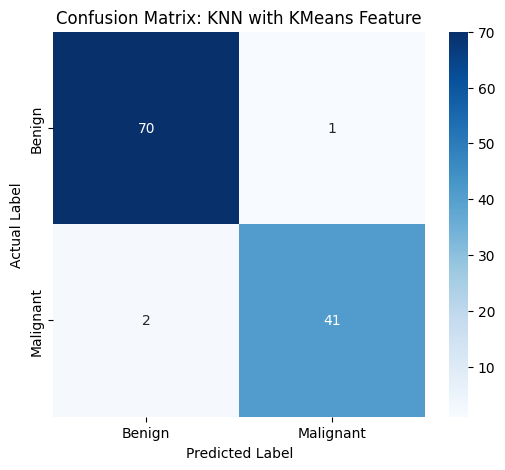

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Pass the KMeans cluster assignments into KNN as an extra feature
kmeans_test_clusters = kmeans_unsupervised.predict(X_test)
X_train_with_cluster = np.column_stack((X_train, train_clusters))
X_test_with_cluster = np.column_stack((X_test, kmeans_test_clusters))

knn_with_clusters = KNeighborsClassifier(n_neighbors=5)
knn_with_clusters.fit(X_train_with_cluster, y_train)
y_pred_with_clusters = knn_with_clusters.predict(X_test_with_cluster)

print("KNN with KMeans feature results:")
print("Accuracy:", accuracy_score(y_test, y_pred_with_clusters))
print("Precision:", precision_score(y_test, y_pred_with_clusters))
print("Recall:", recall_score(y_test, y_pred_with_clusters))
print("F1 Score:", f1_score(y_test, y_pred_with_clusters))
print("\nClassification Report:\n", classification_report(y_test, y_pred_with_clusters, target_names=["Benign", "Malignant"]))
# Display the confusion matrix for the KNN model with KMeans features
cm = confusion_matrix(y_test, y_pred_with_clusters)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix: KNN with KMeans Feature")
plt.show()

SVM with KMeans feature results:
Accuracy: 0.9649122807017544
Precision: 0.975609756097561
Recall: 0.9302325581395349
F1 Score: 0.9523809523809523

Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        71
   Malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



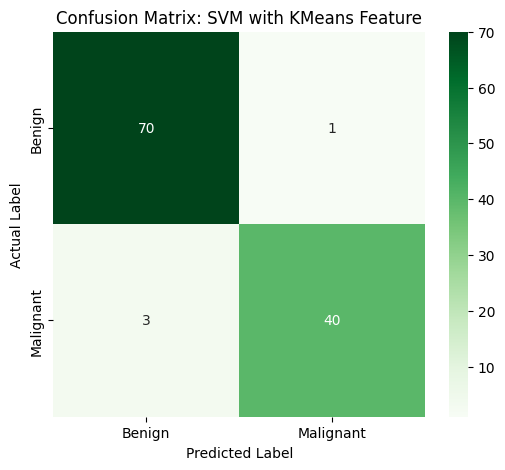

In [18]:
from sklearn.svm import SVC

# Apply SVM on the KMeans-augmented breast cancer data
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_with_cluster, y_train)
y_pred_svm = svm_model.predict(X_test_with_cluster)

print("SVM with KMeans feature results:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, target_names=["Benign", "Malignant"]))
# Confusion matrix for SVM model
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens", xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix: SVM with KMeans Feature")
plt.show()

Random Forest with KMeans feature results:
Accuracy: 0.9649122807017544
Precision: 0.975609756097561
Recall: 0.9302325581395349
F1 Score: 0.9523809523809523

Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        71
   Malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



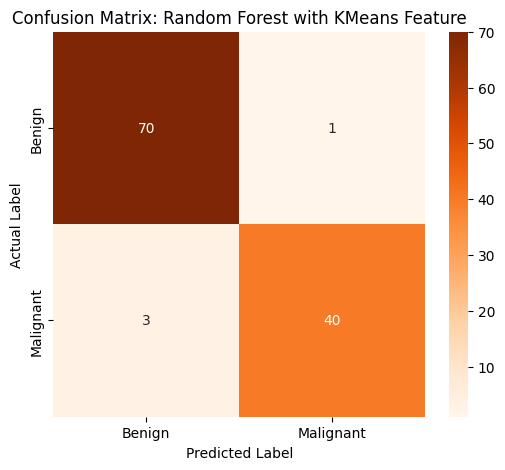

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Apply Random Forest on the KMeans-augmented breast cancer data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_with_cluster, y_train)
y_pred_rf = rf_model.predict(X_test_with_cluster)

print("Random Forest with KMeans feature results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=["Benign", "Malignant"]))
# Confusion matrix for Random Forest model
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges", xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix: Random Forest with KMeans Feature")
plt.show()

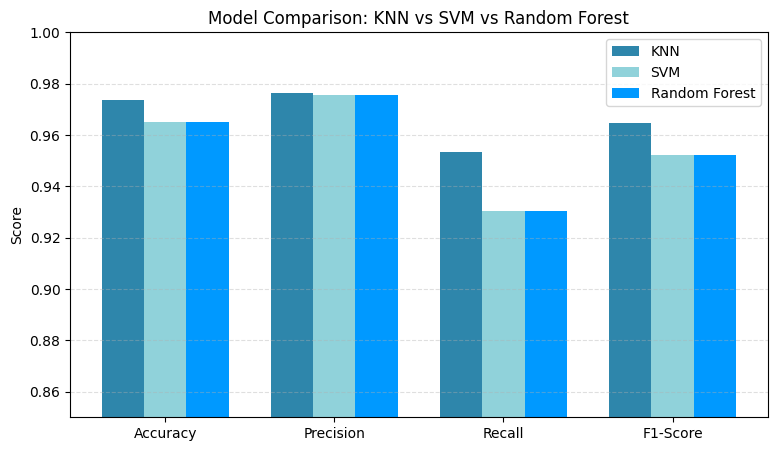

In [26]:
# Comparative bar graph for KNN, SVM, and Random Forest
knn_scores = [
    accuracy_score(y_test, y_pred_with_clusters),
    precision_score(y_test, y_pred_with_clusters),
    recall_score(y_test, y_pred_with_clusters),
    f1_score(y_test, y_pred_with_clusters)
]

svm_scores = [
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm)
]

rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metric_names))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, knn_scores, width, label="KNN", color="#2E86AB")
plt.bar(x, svm_scores, width, label="SVM", color="#90D2DA")
plt.bar(x + width, rf_scores, width, label="Random Forest", color="#0099FF")

plt.xticks(x, metric_names)
plt.ylim(0.85, 1.0)
plt.ylabel("Score")
plt.title("Model Comparison: KNN vs SVM vs Random Forest")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()